In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv('loan approval data.csv')

In [ ]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [ ]:
df.isnull().sum()

,0
Applicant_ID,50
Applicant_Income,50
Coapplicant_Income,50
Employment_Status,50
Age,50
Marital_Status,50
Dependents,50
Credit_Score,50
Existing_Loans,50
DTI_Ratio,50


In [ ]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


## Handling missing Values

 As we know for the numerical Feature we generally use mean and in some case we use median

And for the Categorical Value we generally use mode (we take the most repeated )

In [ ]:
categorical_features = [feature for feature in df.columns if df[feature].dtypes == 'O']

In [ ]:
categorical_features

['Employment_Status',
 'Marital_Status',
 'Loan_Purpose',
 'Property_Area',
 'Education_Level',
 'Gender',
 'Employer_Category',
 'Loan_Approved']

In [ ]:
numerical_features = [feature for feature in df.columns if df[feature].dtypes != 'O']

In [ ]:
numerical_features

['Applicant_ID',
 'Applicant_Income',
 'Coapplicant_Income',
 'Age',
 'Dependents',
 'Credit_Score',
 'Existing_Loans',
 'DTI_Ratio',
 'Savings',
 'Collateral_Value',
 'Loan_Amount',
 'Loan_Term']

In [ ]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy='mean')
num_imp.fit(df[numerical_features])
cat_imp = SimpleImputer(strategy='most_frequent')
cat_imp.fit(df[categorical_features])
df[numerical_features] = num_imp.transform(df[numerical_features])
df[categorical_features] = cat_imp.transform(df[categorical_features])



In [ ]:
df.isnull().sum()

,0
Applicant_ID,0
Applicant_Income,0
Coapplicant_Income,0
Employment_Status,0
Age,0
Marital_Status,0
Dependents,0
Credit_Score,0
Existing_Loans,0
DTI_Ratio,0


#EDA


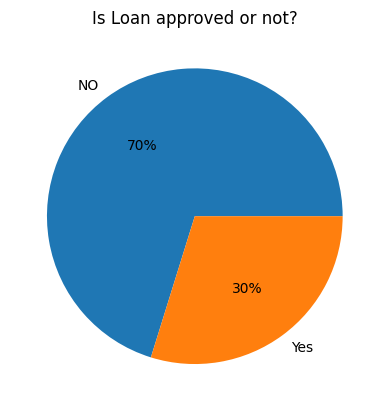

In [ ]:
## How Balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["NO","Yes"], autopct='%1.0f%%')
plt.title("Is Loan approved or not?")
plt.show()
#

[Text(0, 0, '621'), Text(0, 0, '379')]

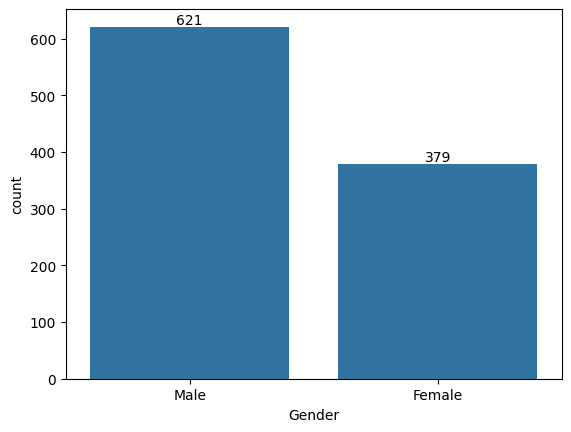

In [ ]:
## Analyze Categories

gender_count = df["Gender"].value_counts()
ax= sns.barplot(gender_count)
ax.bar_label(ax.containers[0])


[Text(0, 0, '722'), Text(0, 0, '278')]

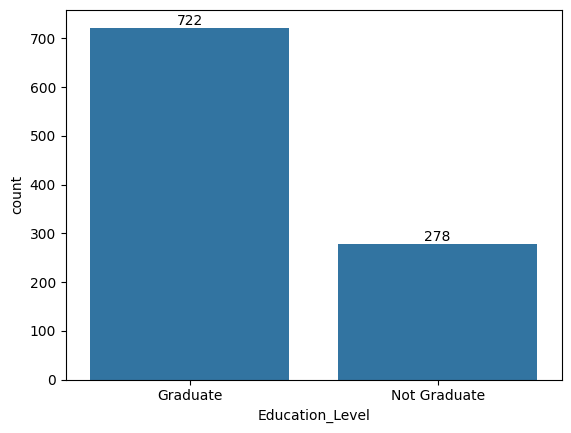

In [ ]:
edc_count = df["Education_Level"].value_counts()
ax= sns.barplot(edc_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

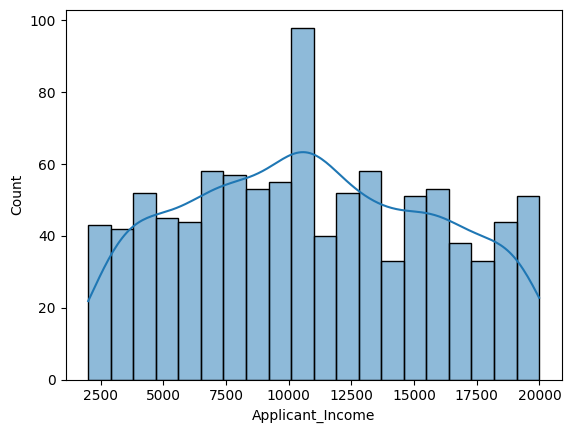

In [ ]:
## Analyze Income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    kde = True,
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

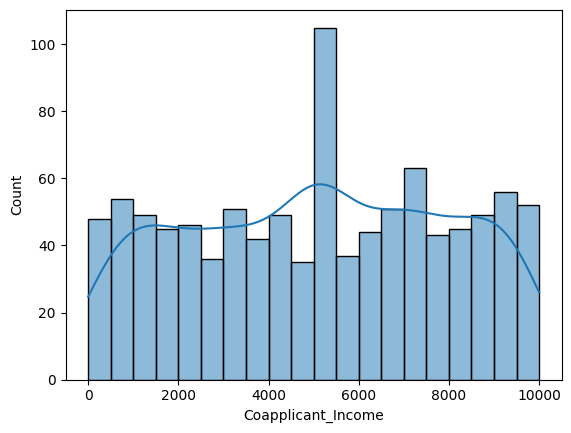

In [ ]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    kde = True,
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

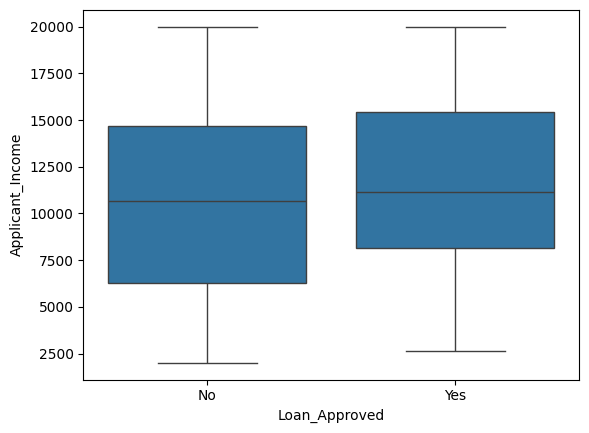

In [ ]:
## Outliers - Box Plot
sns.boxplot(
    data = df,
    y="Applicant_Income",x = "Loan_Approved")

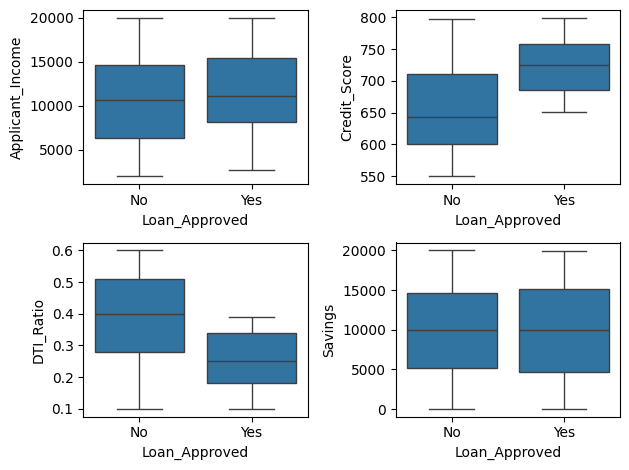

In [ ]:
fig, axes = plt.subplots(2, 2)
sns.boxplot(ax = axes[0,0],data = df,y="Applicant_Income",x = "Loan_Approved")
sns.boxplot(ax = axes[0,1],data = df,y="Credit_Score",x = "Loan_Approved")
sns.boxplot(ax = axes[1,0],data = df,y="DTI_Ratio",x = "Loan_Approved")
sns.boxplot(ax = axes[1,1],data = df,y="Savings",x = "Loan_Approved")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

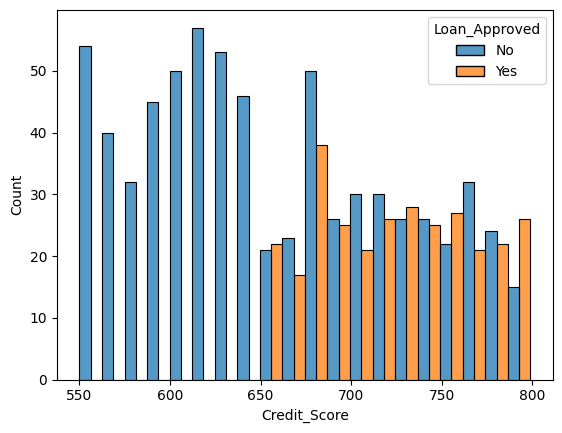

In [ ]:
## Credit Score with Loan Approved

sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)

In [ ]:
## Remove Applicant Id
if 'Applicant_ID' in df.columns:
    df.drop('Applicant_ID', axis=1, inplace=True)
else:
    print("'Applicant_ID' column not found in DataFrame.")

In [ ]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Encoding
LabelEncoder - Assigns an integer to each category

OneHotEncoder - Creates binary columns for each Category

In [ ]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

# Label encoding
le_edu = LabelEncoder()
df["Education_Level"] = le_edu.fit_transform(df["Education_Level"])

le_target = LabelEncoder()
df["Loan_Approved"] = le_target.fit_transform(df["Loan_Approved"])

# One hot encoding
cols = ['Employment_Status', 'Marital_Status', 'Loan_Purpose',
        'Property_Area', 'Gender', 'Employer_Category']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

# replace columns
df = df.drop(columns=cols)
df = pd.concat([df, encoded_df], axis=1)


In [ ]:
## SAVING THE DATASET
df.to_csv("cleaned_loan_data.csv", index=False)


In [ ]:
# df = pd.concat([df,encoded_df], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap


In [ ]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

In [ ]:
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.013108,-0.025975,0.013923,-0.026566


In [ ]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

,Loan_Approved
Loan_Approved,1.000000
Credit_Score,0.451175
Applicant_Income,0.119796
Employer_Category_MNC,0.069049
Loan_Purpose_Personal,0.034043
Marital_Status_Single,0.030182
Property_Area_Urban,0.025963
Collateral_Value,0.021868
Coapplicant_Income,0.004230
Loan_Purpose_Home,0.002118


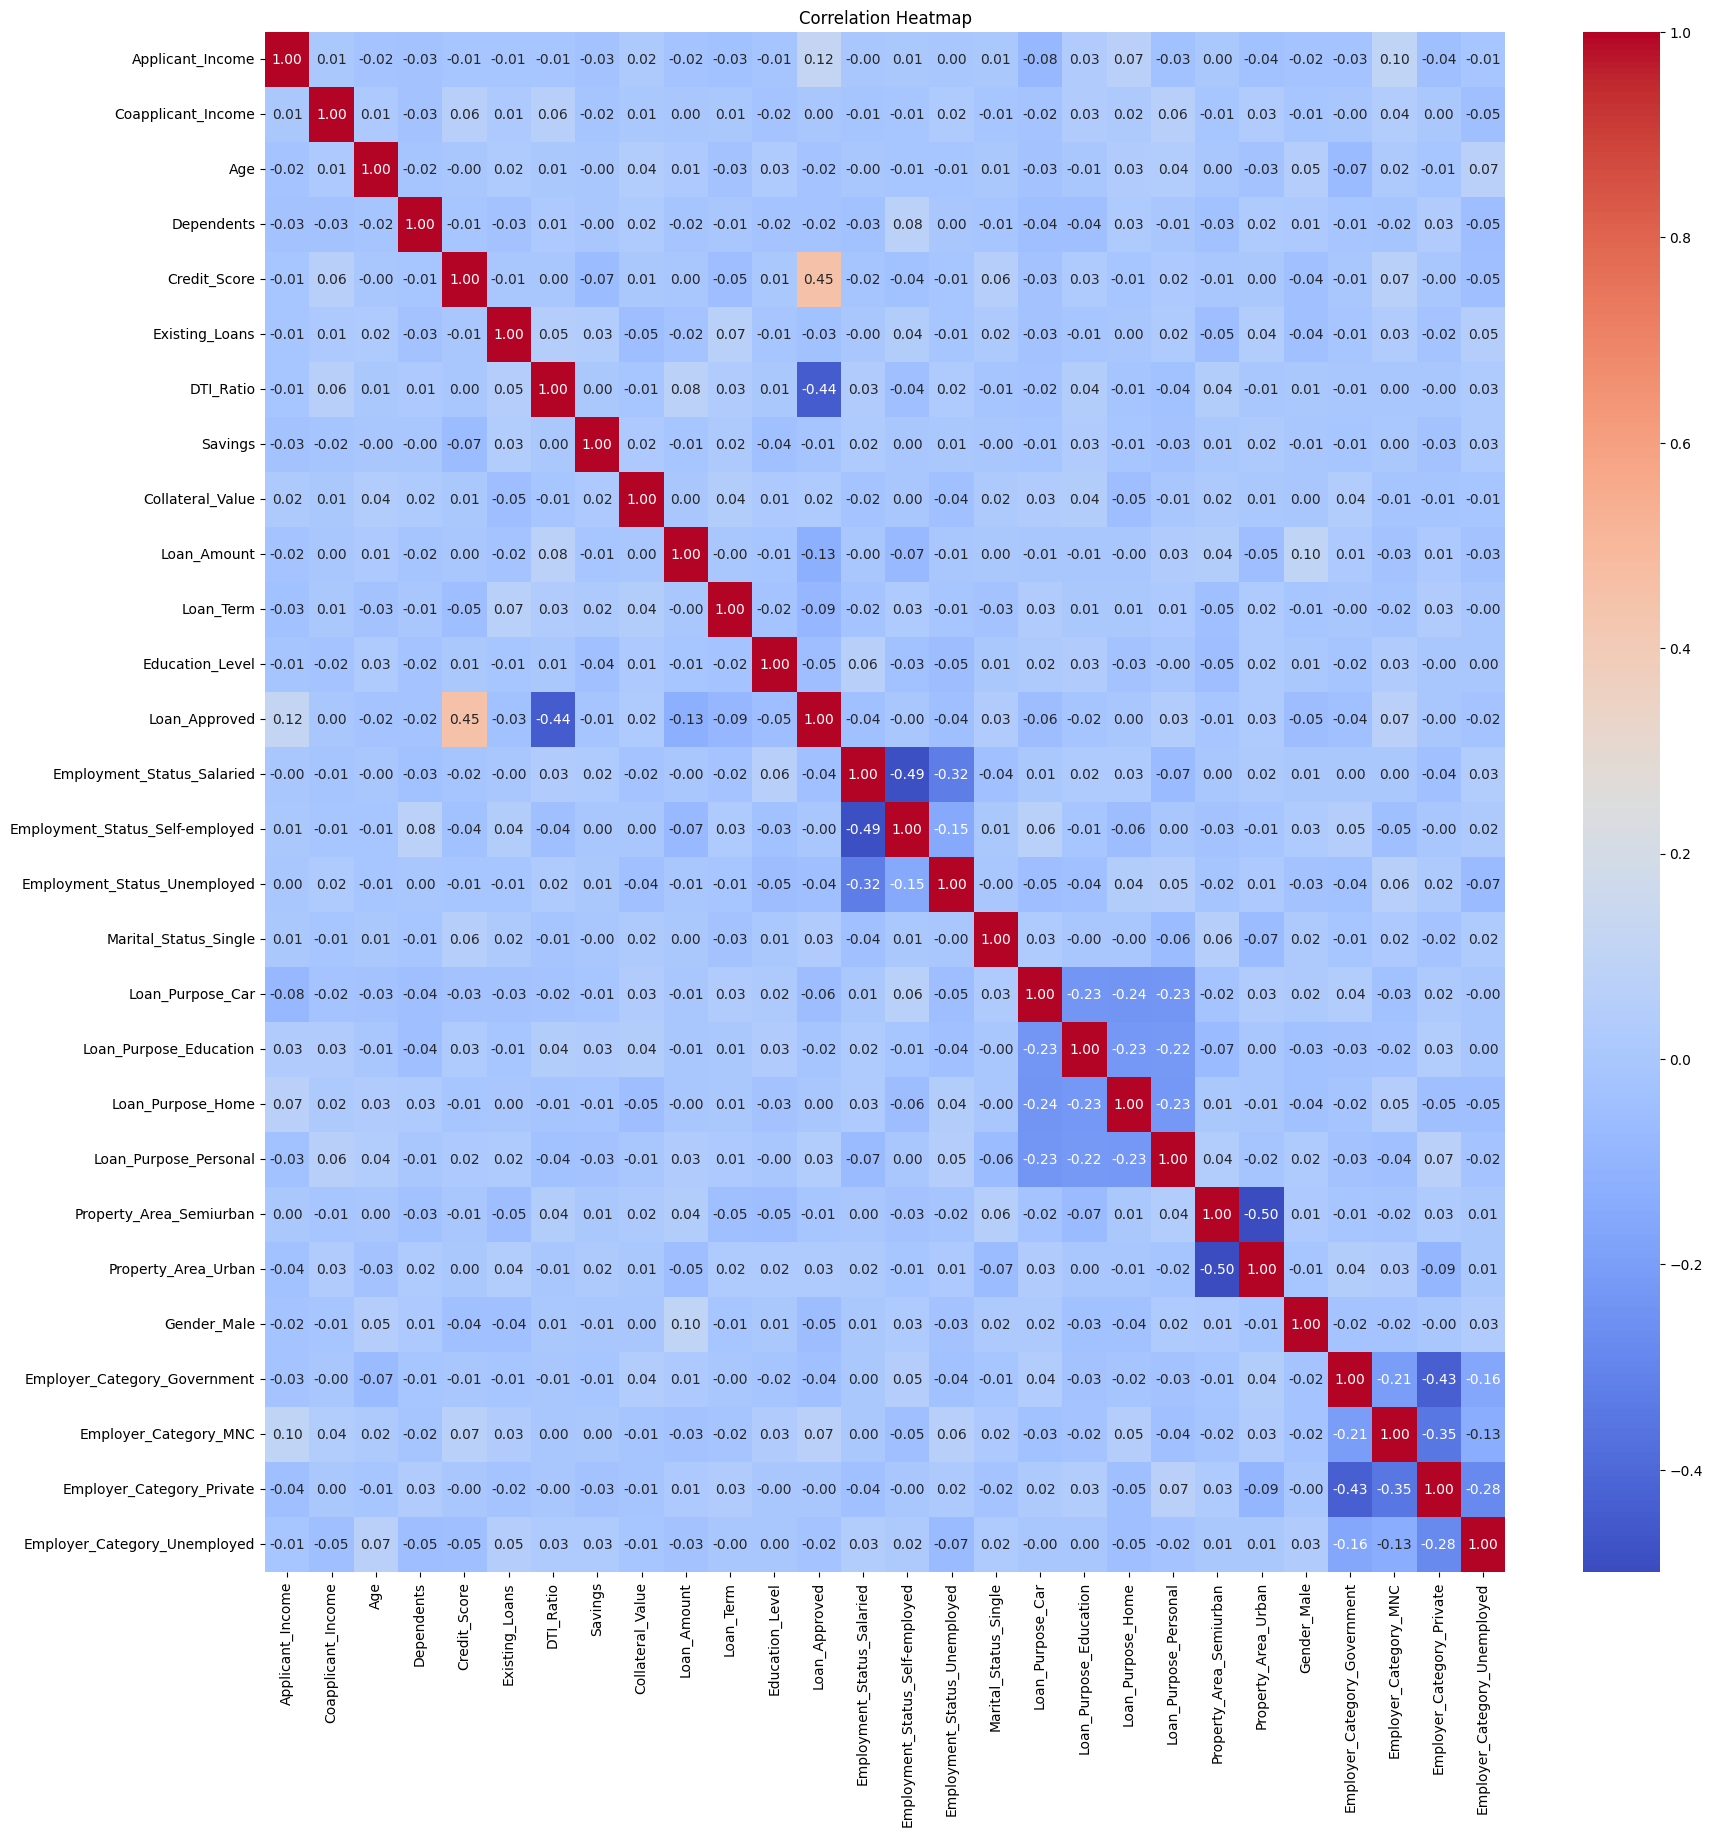

In [ ]:
plt.figure(figsize=(20, 20
                    ))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Train Test Split

In [ ]:
X = df.drop("Loan_Approved", axis = 1)
y = df['Loan_Approved']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
## Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#Train and Evaluate Model

In [ ]:
## Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
log_model = LogisticRegression(C= 10, max_iter= 200, penalty= 'l1', solver= 'liblinear')
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

### Evaluation

print("Precision", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("classification_report",classification_report(y_test, y_pred))
print("accuracy_score",accuracy_score(y_test, y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))


Precision 0.7868852459016393
Recall 0.7868852459016393
F1 Score 0.7868852459016393
classification_report               precision    recall  f1-score   support

           0       0.91      0.91      0.91       139
           1       0.79      0.79      0.79        61

    accuracy                           0.87       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.87      0.87      0.87       200

accuracy_score 0.87
confusion matrix [[126  13]
 [ 13  48]]


# Hyperparameter tuning for Logistic Regression


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, precision_score
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

param_grid_log = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500]
}

grid_log = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid_log,
    cv=5,
    scoring='precision',   # IMPORTANT for loan approval
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Best Parameters:", grid_log.best_params_)
print("Best Precision:", grid_log.best_score_)

Best Parameters: {'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Precision: 0.7693355852102061


In [ ]:
## KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

### Evaluation

print("Precision", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("classification_report",classification_report(y_test, y_pred))
print("accuracy_score",accuracy_score(y_test, y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))

Precision 0.6274509803921569
Recall 0.5245901639344263
F1 Score 0.5714285714285714
classification_report               precision    recall  f1-score   support

           0       0.81      0.86      0.83       139
           1       0.63      0.52      0.57        61

    accuracy                           0.76       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.75      0.76      0.75       200

accuracy_score 0.76
confusion matrix [[120  19]
 [ 29  32]]


#Hyperparameter Tuning

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # only used when metric='minkowski'
}

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best KNN Params:", grid_knn.best_params_)
print("Best KNN Precision:", grid_knn.best_score_)

Best KNN Params: {'metric': 'euclidean', 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Best KNN Precision: 0.46612276612276615


In [ ]:
## Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB(var_smoothing= 1e-09)
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

### Evaluation
print("Naive Bayes ")
print("Precision", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("classification_report",classification_report(y_test, y_pred))
print("accuracy_score",accuracy_score(y_test, y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))

Naive Bayes 
Precision 0.8035714285714286
Recall 0.7377049180327869
F1 Score 0.7692307692307693
classification_report               precision    recall  f1-score   support

           0       0.89      0.92      0.90       139
           1       0.80      0.74      0.77        61

    accuracy                           0.86       200
   macro avg       0.85      0.83      0.84       200
weighted avg       0.86      0.86      0.86       200

accuracy_score 0.865
confusion matrix [[128  11]
 [ 16  45]]


## Hyperparameter Tuning


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid_nb,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)

print("Best NB Params:", grid_nb.best_params_)
print("Best NB Precision:", grid_nb.best_score_)

Best NB Params: {'var_smoothing': 1e-09}
Best NB Precision: 0.6074673046251994


In [ ]:
## Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# create model
dt_model = DecisionTreeClassifier(
    criterion='gini',      # or 'entropy'
    max_depth=5,           # helps avoid overfitting
    random_state=42
)

# train
dt_model.fit(X_train, y_train)

# predict
y_pred_dt = dt_model.predict(X_test)

# evaluation
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Results
Accuracy: 0.915
Precision: 0.8235294117647058
Recall: 0.9180327868852459
F1 Score: 0.8682170542635659
Confusion Matrix:
 [[127  12]
 [  5  56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.94       139
           1       0.82      0.92      0.87        61

    accuracy                           0.92       200
   macro avg       0.89      0.92      0.90       200
weighted avg       0.92      0.92      0.92       200



# Hyperparameter Tuning

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}
## Not Working
grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best Precision:", grid_dt.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Precision: 0.8890823462252033


In [ ]:
## SVC
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# create model
svm_model = SVC(
    kernel='rbf',     # best general kernel
    C=1.0,
    gamma='scale',
    random_state=42
)

# train
svm_model.fit(X_train_scaled, y_train)

# predict
y_pred_svm = svm_model.predict(X_test_scaled)

# evaluation
print("SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))


SVM Results
Accuracy: 0.865
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1 Score: 0.7692307692307693
Confusion Matrix:
 [[128  11]
 [ 16  45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90       139
           1       0.80      0.74      0.77        61

    accuracy                           0.86       200
   macro avg       0.85      0.83      0.84       200
weighted avg       0.86      0.86      0.86       200



## Hyperparameter Tuning

In [ ]:
from sklearn.svm import SVC

svm_model = SVC()

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best Precision:", grid_svm.best_score_)

In [ ]:
## Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


## Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

param_grid_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Precision:", grid_rf.best_score_)

In [ ]:
## AdaBoost

from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print("AdaBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:", recall_score(y_test, y_pred_ada))
print("F1 Score:", f1_score(y_test, y_pred_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("Classification Report:\n", classification_report(y_test, y_pred_ada))


#Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

ada_model = AdaBoostClassifier()

param_grid_ada = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1],
    'estimator': [DecisionTreeClassifier(max_depth=1),
                  DecisionTreeClassifier(max_depth=2),
                  DecisionTreeClassifier(max_depth=3)]
}

grid_ada = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid_ada,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

print("Best Parameters:", grid_ada.best_params_)
print("Best Precision:", grid_ada.best_score_)

In [ ]:
## Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))


## Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best Parameters:", grid_gb.best_params_)
print("Best Precision:", grid_gb.best_score_)

In [ ]:
## XG Boost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))


## Hyperparameter Tuning

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'gamma': [0, 0.1, 0.3]
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best Precision:", grid_xgb.best_score_)

# scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# xgb_model = XGBClassifier(
#     use_label_encoder=False,
#     eval_metric='logloss',
#     scale_pos_weight=scale_pos_weight
# )

In [ ]:
# ==========================================
# 1. Imports
# ==========================================
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from xgboost import XGBClassifier


# ==========================================
# 2. Evaluation Function
# ==========================================
def evaluate_model(true, predicted):

    # Classification metrics
    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted, average='weighted')
    recall = recall_score(true, predicted, average='weighted')
    f1 = f1_score(true, predicted, average='weighted')
    cm = confusion_matrix(true, predicted)

    # Regression-style metrics
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)

    return accuracy, precision, recall, f1, mae, mse, rmse, r2, cm


# ==========================================
# 3. Models Dictionary
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Support Vector Classifier": SVC()
}


# ==========================================
# 4. Training & Evaluation Loop
# ==========================================
for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Test Set
    accuracy, precision, recall, f1, mae, mse, rmse, r2, cm = evaluate_model(y_test, y_test_pred)

    print(f"\nModel: {name}")
    print("="*60)

    print("---- Classification Metrics (Test Set) ----")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\n---- Error Metrics (Test Set) ----")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    print("="*60)


## Best model on the basis of Precision => XG Boost

## Feature Engineering

In [ ]:
## Add or Tranasform Feature
df['DTI_Ratio_sq'] = df['DTI_Ratio'] ** 2
df['Credit_Score_sq'] = df['Credit_Score']**2
df["Total_Income"] = df["Applicant_Income"] + df["Coapplicant_Income"]
df["Income_to_Loan_Ratio"] = df["Total_Income"] / (df["Loan_Amount"] + 1)
df["Loan_per_Month"] = df["Loan_Amount"] / (df["Loan_Term"] + 1)
df["Credit_per_Loan"] = df["Credit_Score"] / (df["Loan_Amount"] + 1)
df["Income_per_Dependent"] = df["Total_Income"] / (df["Dependents"] + 1)
df["Has_Coapplicant"] = (df["Coapplicant_Income"] > 0).astype(int)
df["Savings_to_Loan"] = df["Savings"] / (df["Loan_Amount"] + 1)

X=df.drop(columns = ["Loan_Approved","Credit_Score","DTI_Ratio" ], axis=1)
y=df["Loan_Approved"]

## Train test Split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2 , random_state = 42)

## Scaling
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)



# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])
# df["Savings_sq"] = df["Savings"]**2

In [ ]:
## Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

### Evaluation

print("Precision", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("classification_report",classification_report(y_test, y_pred))
print("accuracy_score",accuracy_score(y_test, y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))


In [ ]:
## KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

### Evaluation

print("Precision", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("classification_report",classification_report(y_test, y_pred))
print("accuracy_score",accuracy_score(y_test, y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))

In [ ]:
## Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

### Evaluation
print("Naive Bayes ")
print("Precision", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("classification_report",classification_report(y_test, y_pred))
print("accuracy_score",accuracy_score(y_test, y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))

In [ ]:
## Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# create model
dt_model = DecisionTreeClassifier(
    criterion='gini',      # or 'entropy'
    max_depth=5,           # helps avoid overfitting
    random_state=42
)

# train
dt_model.fit(X_train, y_train)

# predict
y_pred_dt = dt_model.predict(X_test)

# evaluation
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


In [ ]:
## SVC
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# create model
svm_model = SVC(
    kernel='rbf',     # best general kernel
    C=1.0,
    gamma='scale',
    random_state=42
)

# train
svm_model.fit(X_train_scaled, y_train)

# predict
y_pred_svm = svm_model.predict(X_test_scaled)

# evaluation
print("SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))


In [ ]:
## Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


In [ ]:
## AdaBoost

from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print("AdaBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:", recall_score(y_test, y_pred_ada))
print("F1 Score:", f1_score(y_test, y_pred_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("Classification Report:\n", classification_report(y_test, y_pred_ada))


In [ ]:
## Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))


In [ ]:
## XG Boost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge , Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
## Craete a Function to Evaluate the model
def evaluate_model(true, predicted):
  mae = mean_absolute_error(true, predicted)
  mse = mean_squared_error(true, predicted)
  r2score = r2_score(true, predicted)
  return mae, mse, r2score

In [ ]:
# ==========================================
# 1. Imports
# ==========================================
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from xgboost import XGBClassifier


# ==========================================
# 2. Evaluation Function
# ==========================================
def evaluate_model(true, predicted):

    # Classification metrics
    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted, average='weighted')
    recall = recall_score(true, predicted, average='weighted')
    f1 = f1_score(true, predicted, average='weighted')
    cm = confusion_matrix(true, predicted)

    # Regression-style metrics
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)

    return accuracy, precision, recall, f1, mae, mse, rmse, r2, cm


# ==========================================
# 3. Models Dictionary
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Support Vector Classifier": SVC()
}


# ==========================================
# 4. Training & Evaluation Loop
# ==========================================
for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Test Set
    accuracy, precision, recall, f1, mae, mse, rmse, r2, cm = evaluate_model(y_test, y_test_pred)

    print(f"\nModel: {name}")
    print("="*60)

    print("---- Classification Metrics (Test Set) ----")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\n---- Error Metrics (Test Set) ----")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    print("="*60)
